**Heston**

# Imports

In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
from magic_strikes.heston import HestonModel, get_params_heston

sns.set_theme("talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234
SAVEFIG = False

# Heston

In the Heston model, 

$$
    dS_t = \sqrt{V_t} S_t dW_t^S,
    \quad
    dV_t = \lambda (\bar{V} - V_t) dt + \eta \sqrt{V_t} dW_t^V
    \\
$$

where  $d\langle W^S, W^v \rangle_t = \rho dt$.


We can compute the fair strike of a variance and swap in closed-form:

$$
    M(T) = \bar{V}T + (V_0 - \bar{V}) \frac{1-e^{-\lambda T}}{\lambda}
$$

Set model parameters

In [31]:
set_id = 1
params = get_params_heston(id=set_id)
heston = HestonModel(params)
print(heston)

HestonModel with parameters:
v=0.16, lbd=1.0, vbar=0.04, nu=0.6, rho=-0.8, s0=1.0.


In [32]:
# set maturities
Ts = np.linspace(0.5e-1, 1.0, 15)

# Variance swap

In [33]:
# variance swaps via closed-form formula
var_swaps = heston.var_swap(Ts)

### Fukasawa's formula 

In [34]:
# variance swaps via Gauss-Hermite quadrature
n_quad = 12
var_swaps_quad = heston.var_swap_fukasawa(Ts, n_quad=n_quad, std=10, n_interp=3000)

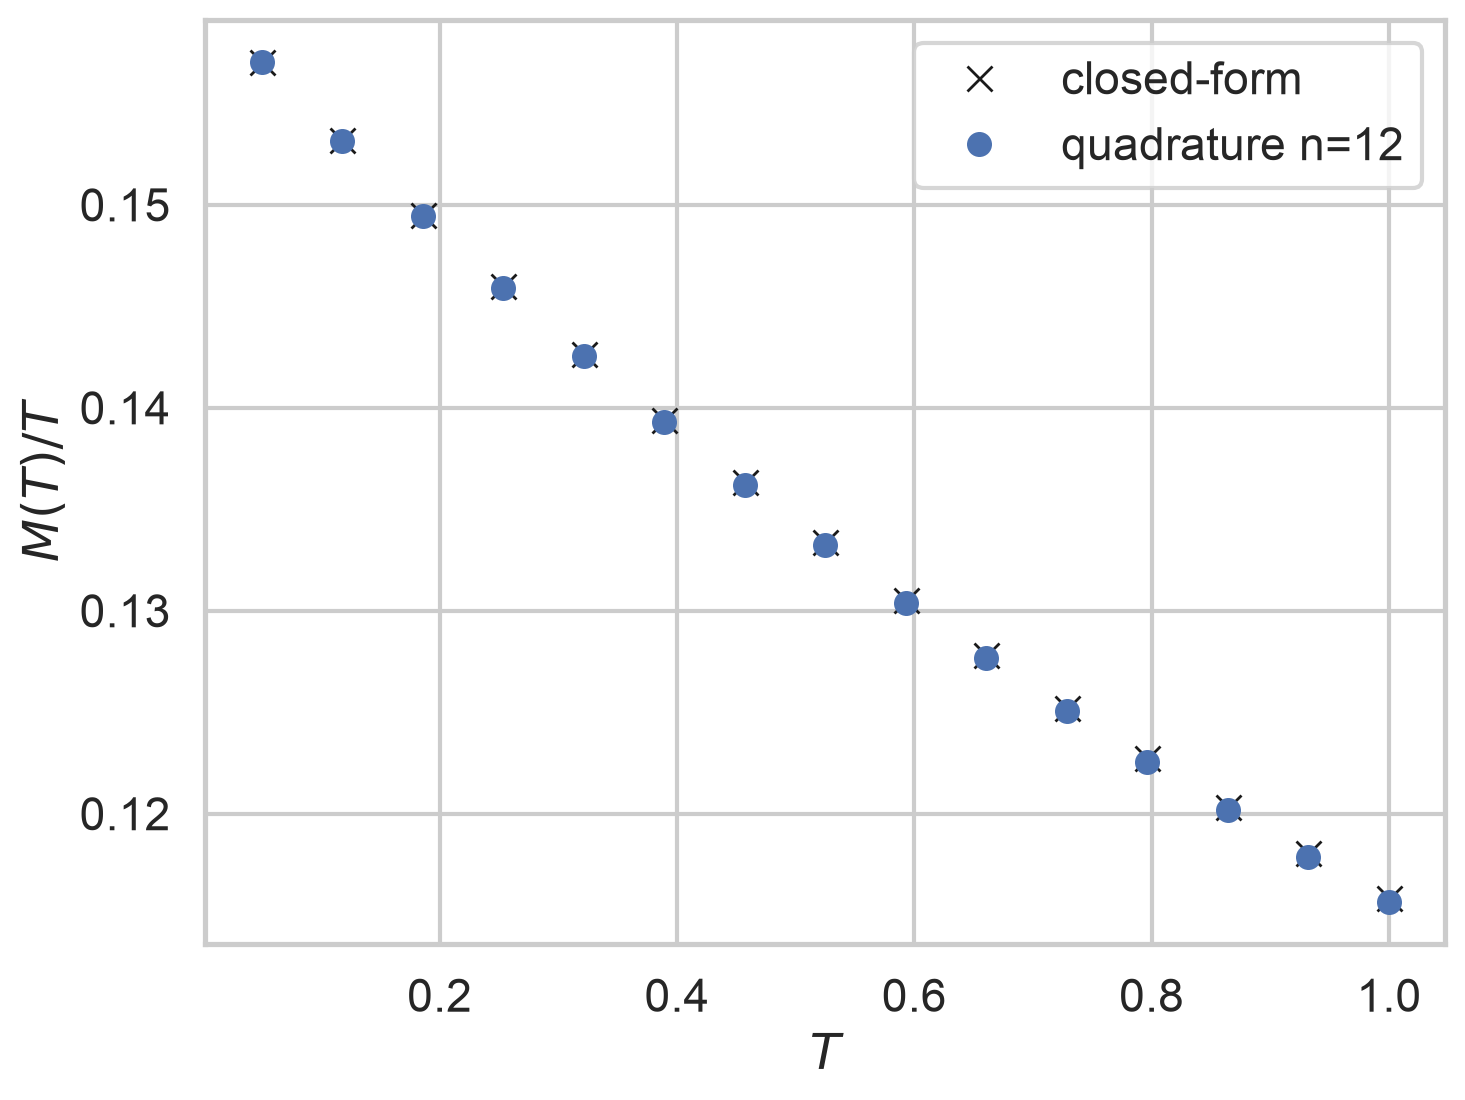

In [35]:
fig, ax = plt.subplots()
ax.plot(Ts, var_swaps / Ts, "kx", linewidth=2, label="closed-form")
ax.plot(Ts, var_swaps_quad / Ts, ".", markersize=16, label=f"quadrature n={n_quad}")
ax.legend()
ax.set_xlabel("$T$")
ax.set_ylabel(r"$M(T) / T$")
plt.show()

### Magic strikes

In [36]:
# list of orders for magic strikes
VS_ORDERS = (1, 2, 3, 4, 5)

In [37]:
# variance swaps via magic strikes
varswaps_magic_strikes = heston.swap_magic_strike(
    T=Ts,
    order=VS_ORDERS,
    opt="variance",
    std=10,
)

Computing magic strikes for T=0.0500... (1/15)
Computing magic strikes for T=0.1179... (2/15)
Computing magic strikes for T=0.1857... (3/15)
Computing magic strikes for T=0.2536... (4/15)
Computing magic strikes for T=0.3214... (5/15)
Computing magic strikes for T=0.3893... (6/15)
Computing magic strikes for T=0.4571... (7/15)
Computing magic strikes for T=0.5250... (8/15)
Computing magic strikes for T=0.5929... (9/15)
Computing magic strikes for T=0.6607... (10/15)
Computing magic strikes for T=0.7286... (11/15)
Computing magic strikes for T=0.7964... (12/15)
Computing magic strikes for T=0.8643... (13/15)
Computing magic strikes for T=0.9321... (14/15)
Computing magic strikes for T=1.0000... (15/15)


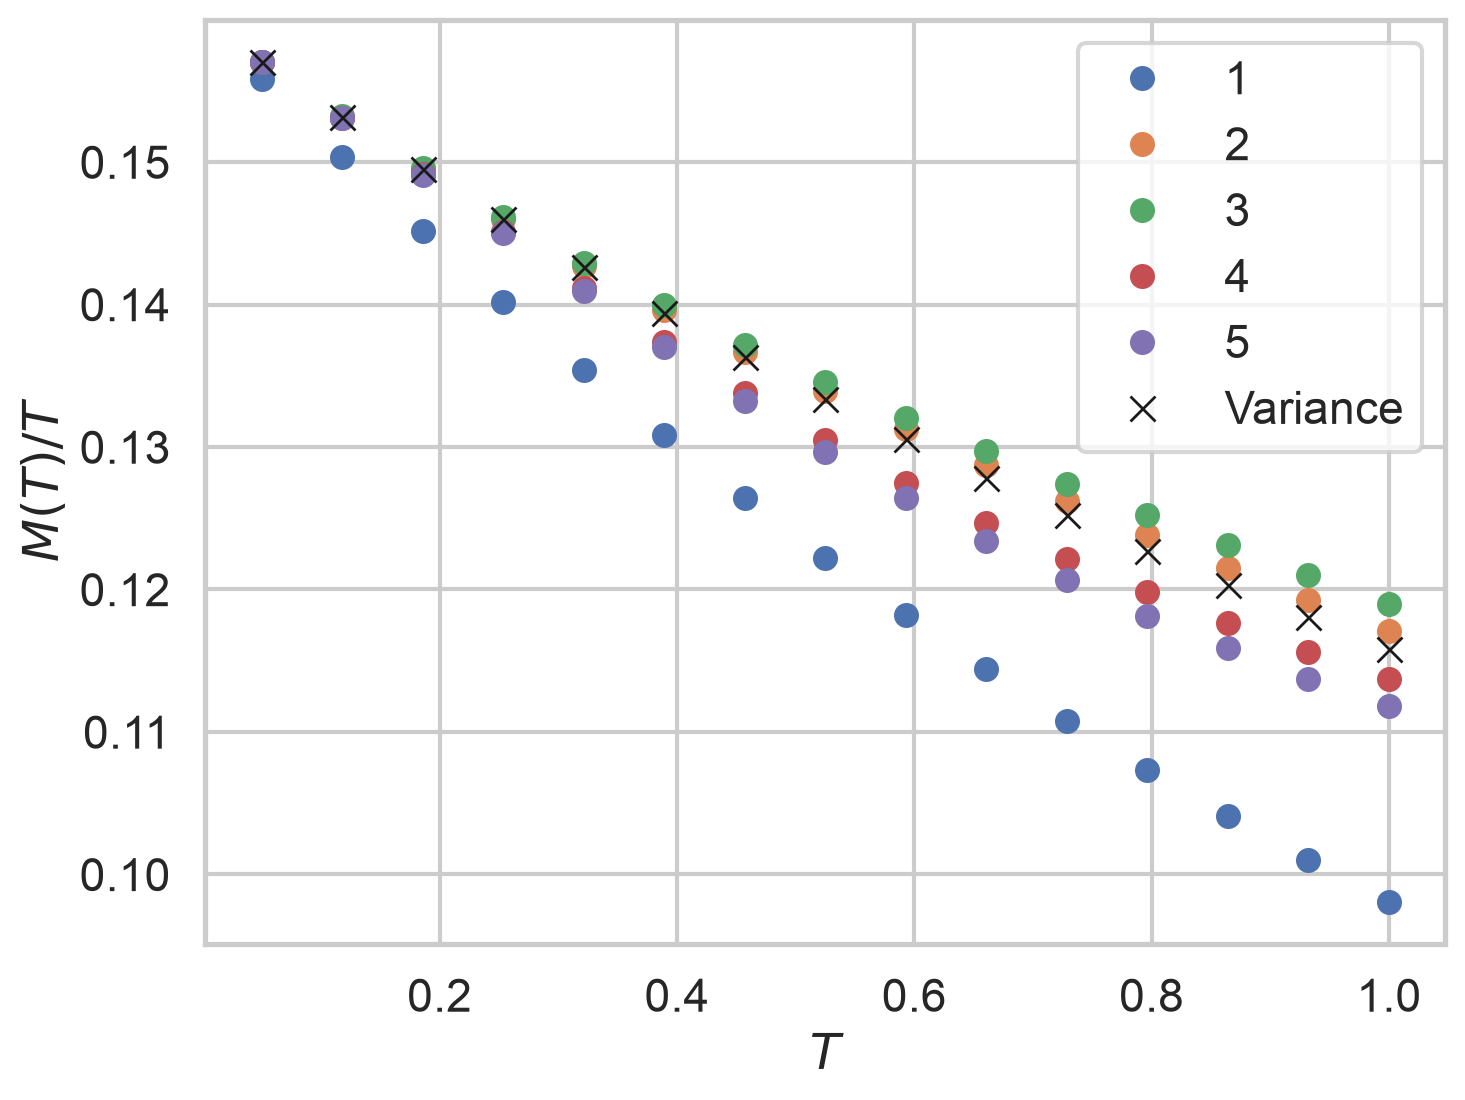

In [38]:
# plot variance swaps vs magic strike approximations
fig, ax = plt.subplots()
for order in VS_ORDERS:
    ax.plot(
        Ts,
        varswaps_magic_strikes[order] / Ts,
        ".",
        markersize=16,
        label=rf"{order}",
    )
ax.plot(Ts, var_swaps / Ts, "kx", label="Variance")
ax.legend()
ax.set_xlabel("$T$")
ax.set_ylabel(r"$M(T)/T$")
if SAVEFIG:
    fig.savefig(
        f"figures/varswap_magic_strikes_heston_set_{set_id}.pdf",
        bbox_inches="tight",
    )
plt.show()

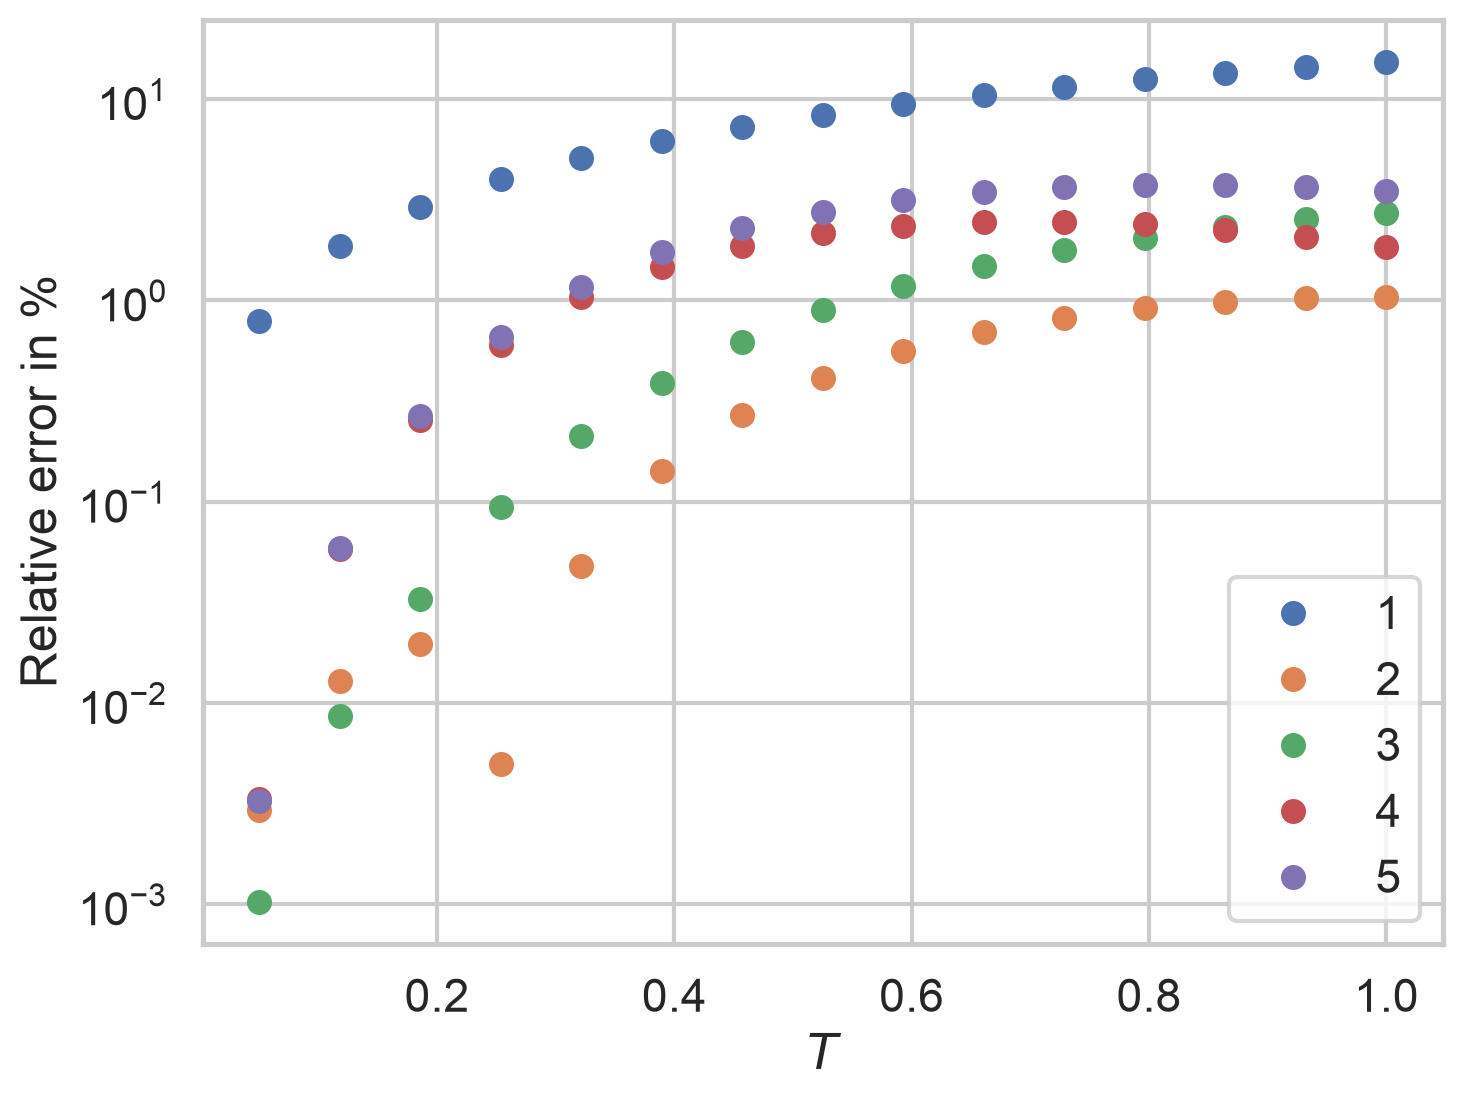

In [39]:
# relative error of magic strikes approximations
rel_error_ms = {
    order: np.abs((var_swaps - varswaps_magic_strikes[order]) / var_swaps)
    for order in VS_ORDERS
}

fig, ax = plt.subplots()
for order in VS_ORDERS:
    ax.semilogy(
        Ts,
        100 * rel_error_ms[order],
        ".",
        markersize=16,
        label=rf"{order}",
    )
ax.legend()
ax.set_xlabel("$T$")
ax.set_ylabel("Relative error in %")
if SAVEFIG:
    fig.savefig(
        f"figures/varswap_magic_strikes_heston_error_set_{set_id}.pdf",
        bbox_inches="tight",
    )
plt.show()

# Gamma swap

In [40]:
gamma_swaps = heston.gamma_swap(Ts)

### Fukasawa

In [41]:
n_quad = 10
gamma_swaps_quad = heston.gamma_swap_fukasawa(Ts, n_quad=n_quad, std=9)

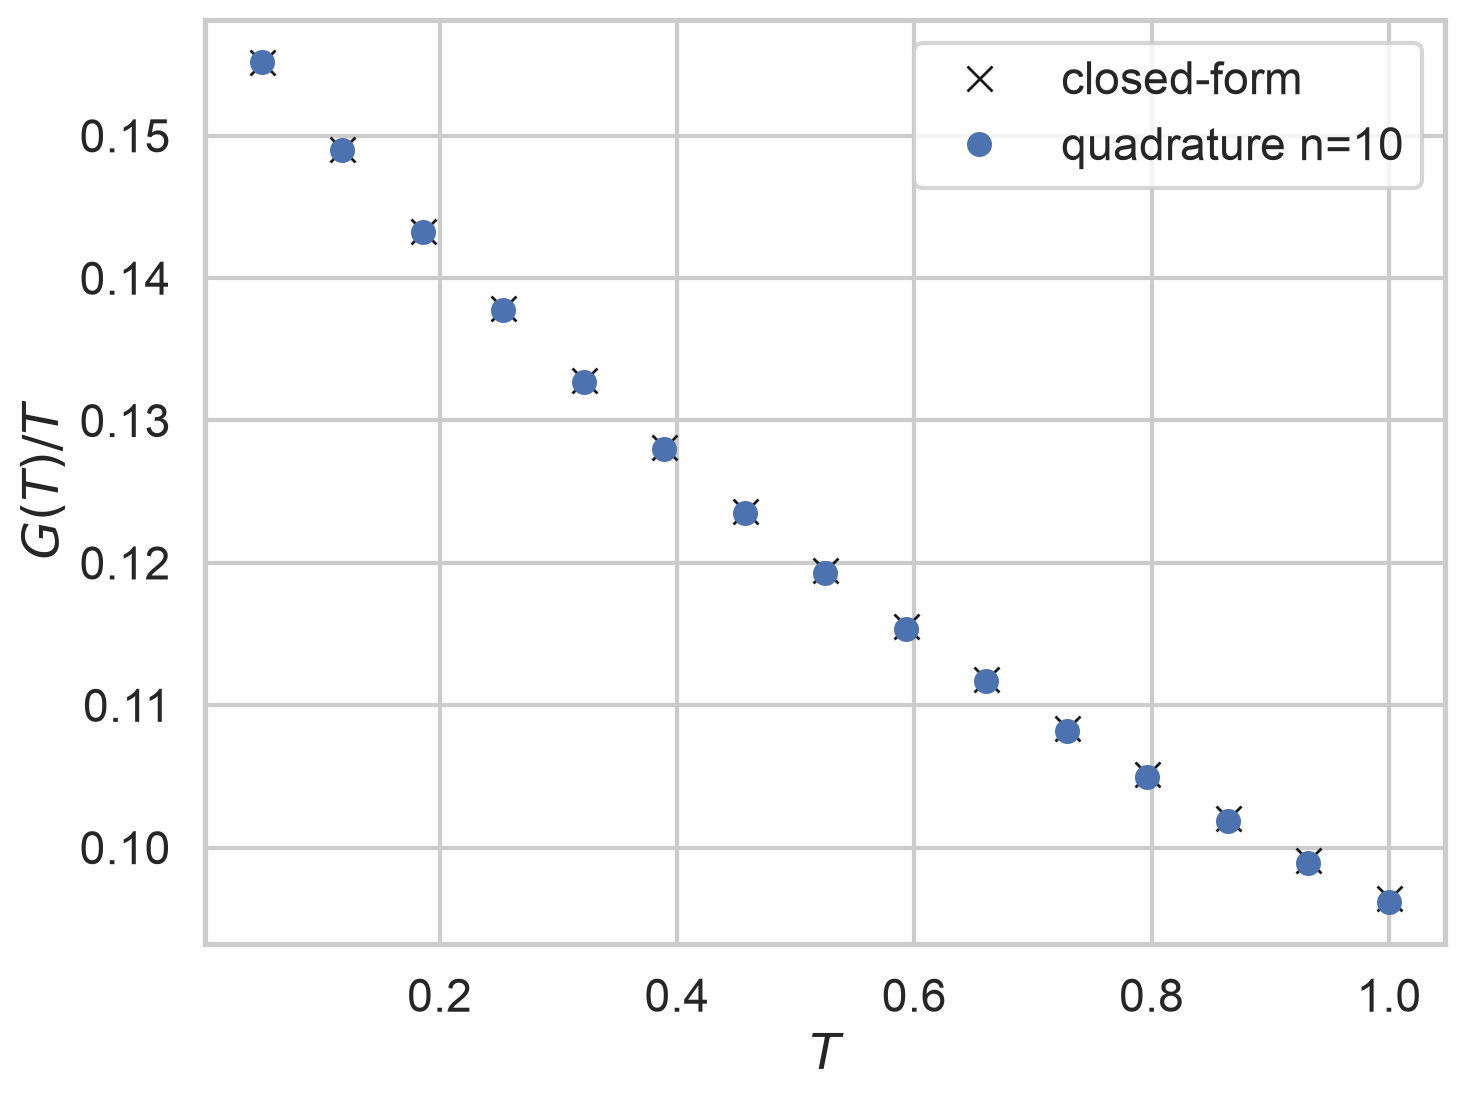

In [42]:
fig, ax = plt.subplots()
ax.plot(Ts, gamma_swaps / Ts, "kx", linewidth=2, label="closed-form")
ax.plot(Ts, gamma_swaps_quad / Ts, ".", markersize=16, label=f"quadrature n={n_quad}")
ax.legend()
ax.set_xlabel("$T$")
ax.set_ylabel(r"$G(T) / T$")
plt.show()

### Magic strikes

In [43]:
GS_ORDERS = (1, 2, 3, 4, 5)
gamma_swaps_magic_strikes = heston.swap_magic_strike(
    T=Ts,
    order=GS_ORDERS,
    opt="gamma",
)

Computing magic strikes for T=0.0500... (1/15)
Computing magic strikes for T=0.1179... (2/15)
Computing magic strikes for T=0.1857... (3/15)
Computing magic strikes for T=0.2536... (4/15)
Computing magic strikes for T=0.3214... (5/15)
Computing magic strikes for T=0.3893... (6/15)
Computing magic strikes for T=0.4571... (7/15)
Computing magic strikes for T=0.5250... (8/15)
Computing magic strikes for T=0.5929... (9/15)
Computing magic strikes for T=0.6607... (10/15)
Computing magic strikes for T=0.7286... (11/15)
Computing magic strikes for T=0.7964... (12/15)
Computing magic strikes for T=0.8643... (13/15)
Computing magic strikes for T=0.9321... (14/15)
Computing magic strikes for T=1.0000... (15/15)


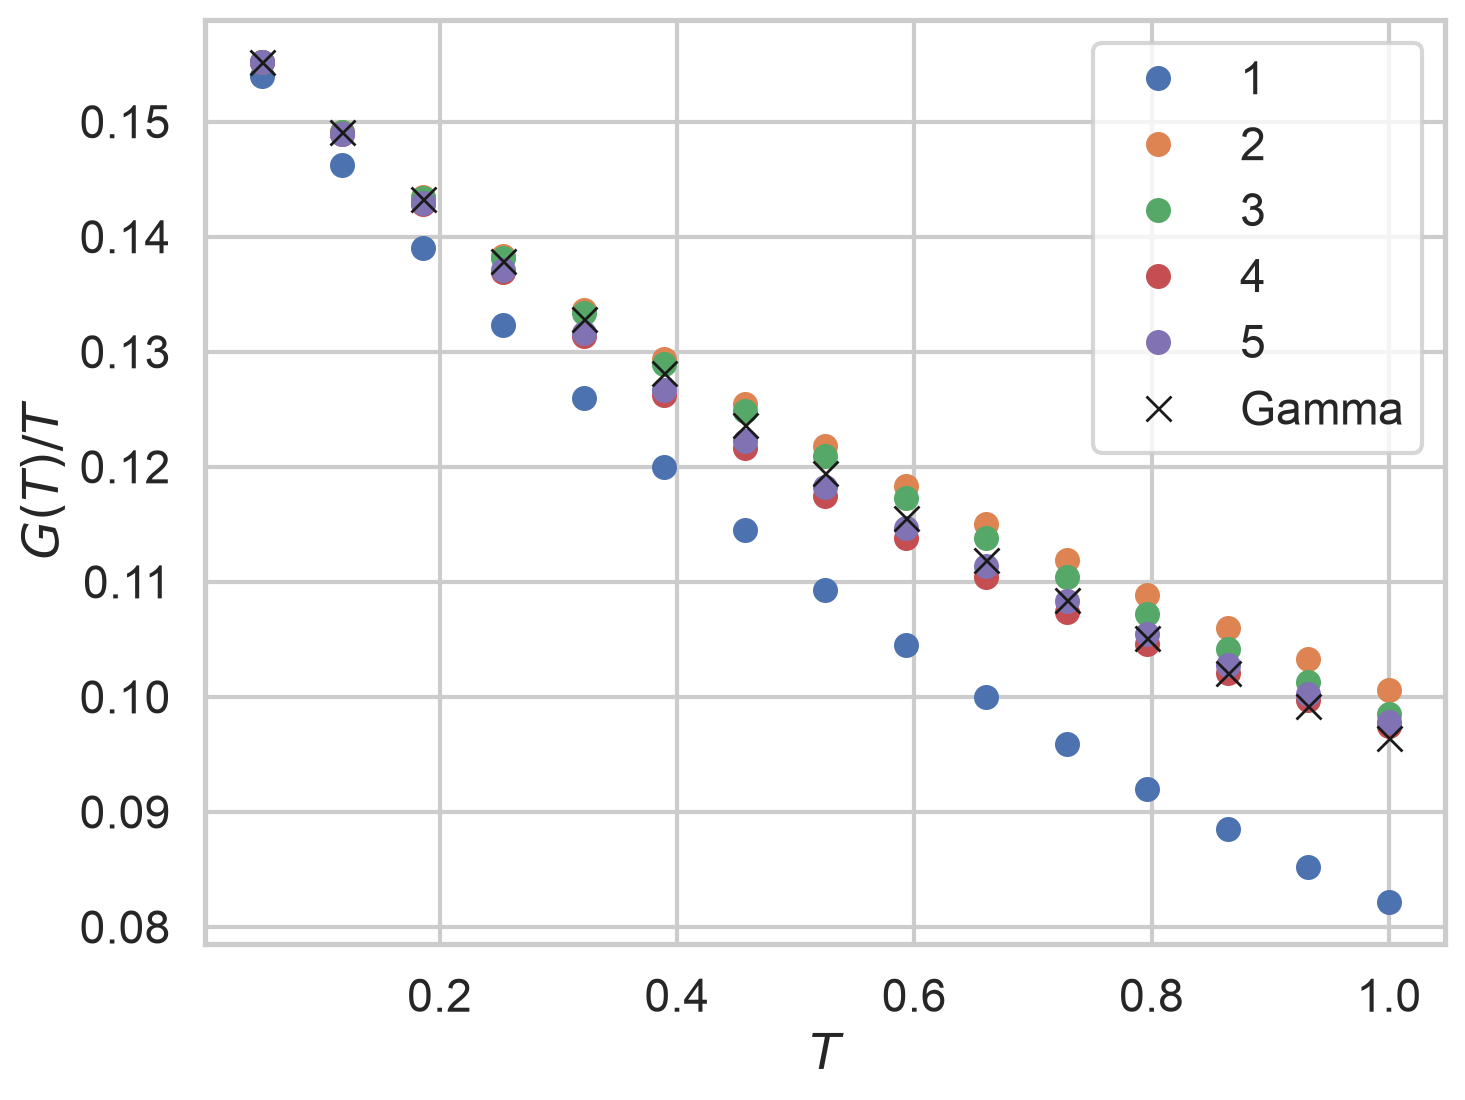

In [44]:
# Plot gamma swaps vs magic strike approximations
fig, ax = plt.subplots()
# fixed-point formula for gamma swap
for order in GS_ORDERS:
    ax.plot(
        Ts,
        gamma_swaps_magic_strikes[order] / Ts,
        ".",
        markersize=16,
        label=rf"{order}",
    )
ax.plot(Ts, gamma_swaps / Ts, "kx", label="Gamma")
ax.legend()
ax.set_xlabel("$T$")
ax.set_ylabel(r"$G(T) / T$")
if SAVEFIG:
    fig.savefig(
        f"figures/gamma_swap_magic_strikes_heston_set_{set_id}.pdf",
        bbox_inches="tight",
    )
plt.show()

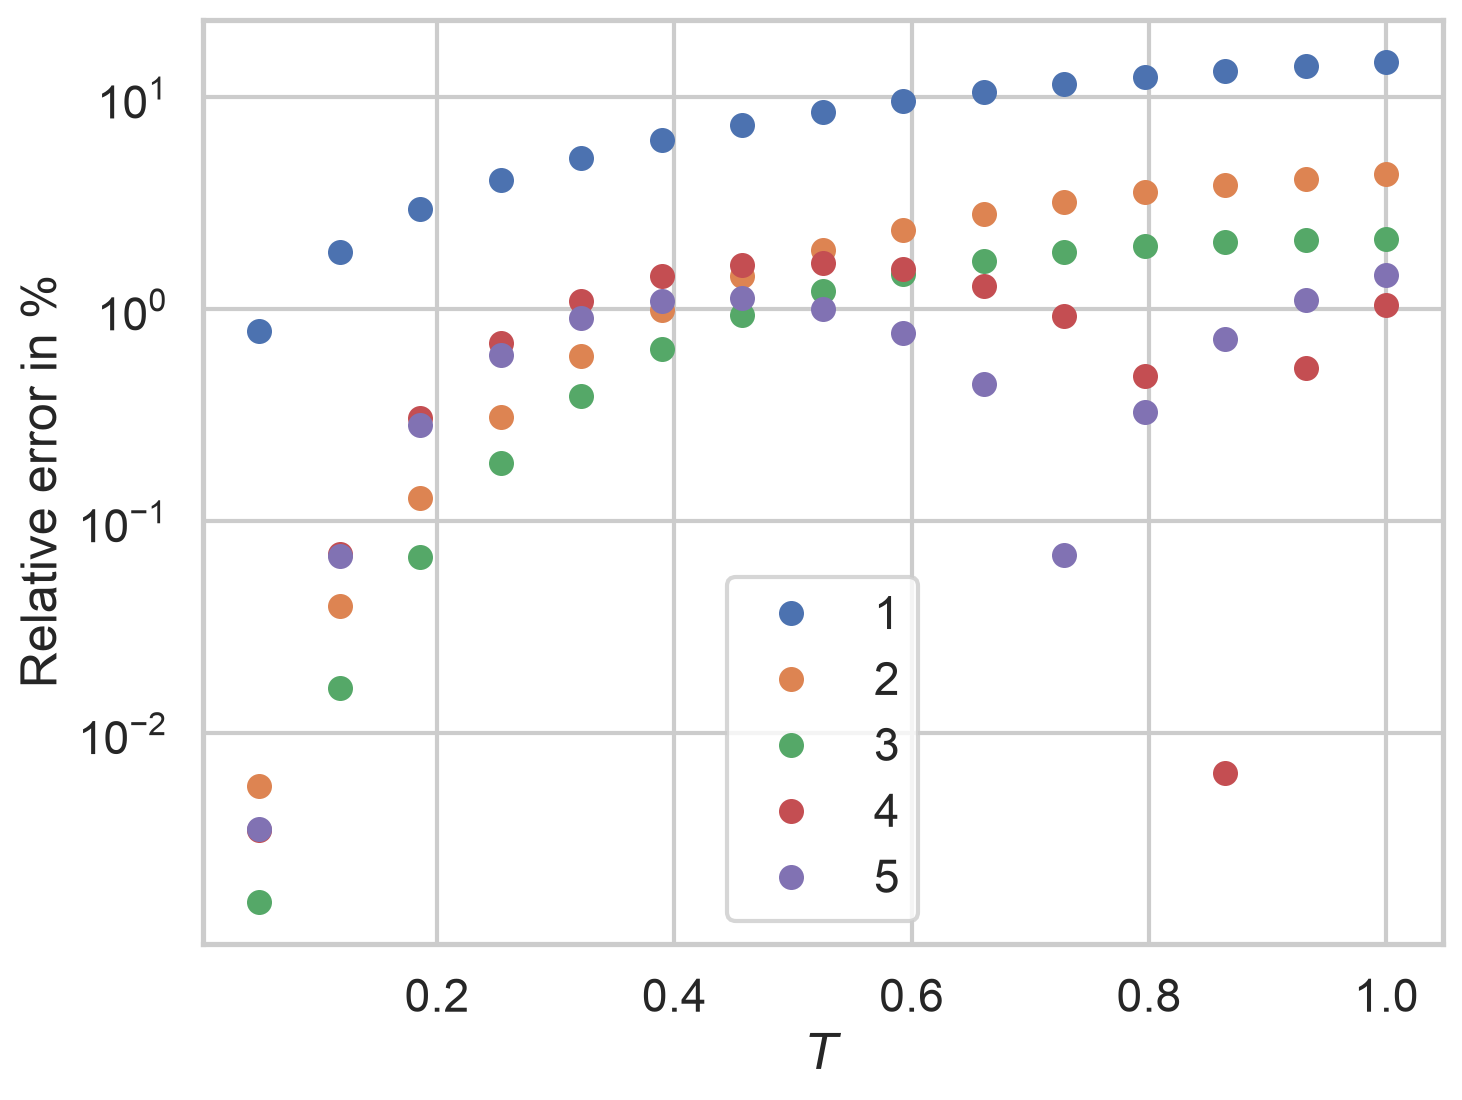

In [45]:
# error of magic strikes approximations
rel_error_ms = {
    order: np.abs(gamma_swaps - gamma_swaps_magic_strikes[order]) / np.abs(gamma_swaps)
    for order in GS_ORDERS
}

fig, ax = plt.subplots()
for order in GS_ORDERS:
    ax.semilogy(
        Ts,
        10**2 * rel_error_ms[order],
        ".",
        markersize=16,
        label=rf"{order}",
    )
ax.legend()
ax.set_xlabel("$T$")
ax.set_ylabel("Relative error in %")
if SAVEFIG:
    fig.savefig(
        f"figures/gamma_swap_magic_strikes_heston_error_set_{set_id}.pdf",
        bbox_inches="tight",
    )
plt.show()

## Power payoff

In [46]:
p = 0.8

In [47]:
power_var = heston.implied_power_variance(Ts, p=p)

In [48]:
POWER_ORDERS = (1, 2, 3, 4, 5)
power_var_magic_strikes = heston.swap_magic_strike(
    T=Ts,
    order=POWER_ORDERS,
    opt="power",
    p=p,
)

Computing magic strikes for T=0.0500... (1/15)
Computing magic strikes for T=0.1179... (2/15)
Computing magic strikes for T=0.1857... (3/15)
Computing magic strikes for T=0.2536... (4/15)
Computing magic strikes for T=0.3214... (5/15)
Computing magic strikes for T=0.3893... (6/15)
Computing magic strikes for T=0.4571... (7/15)
Computing magic strikes for T=0.5250... (8/15)
Computing magic strikes for T=0.5929... (9/15)
Computing magic strikes for T=0.6607... (10/15)
Computing magic strikes for T=0.7286... (11/15)
Computing magic strikes for T=0.7964... (12/15)
Computing magic strikes for T=0.8643... (13/15)
Computing magic strikes for T=0.9321... (14/15)
Computing magic strikes for T=1.0000... (15/15)


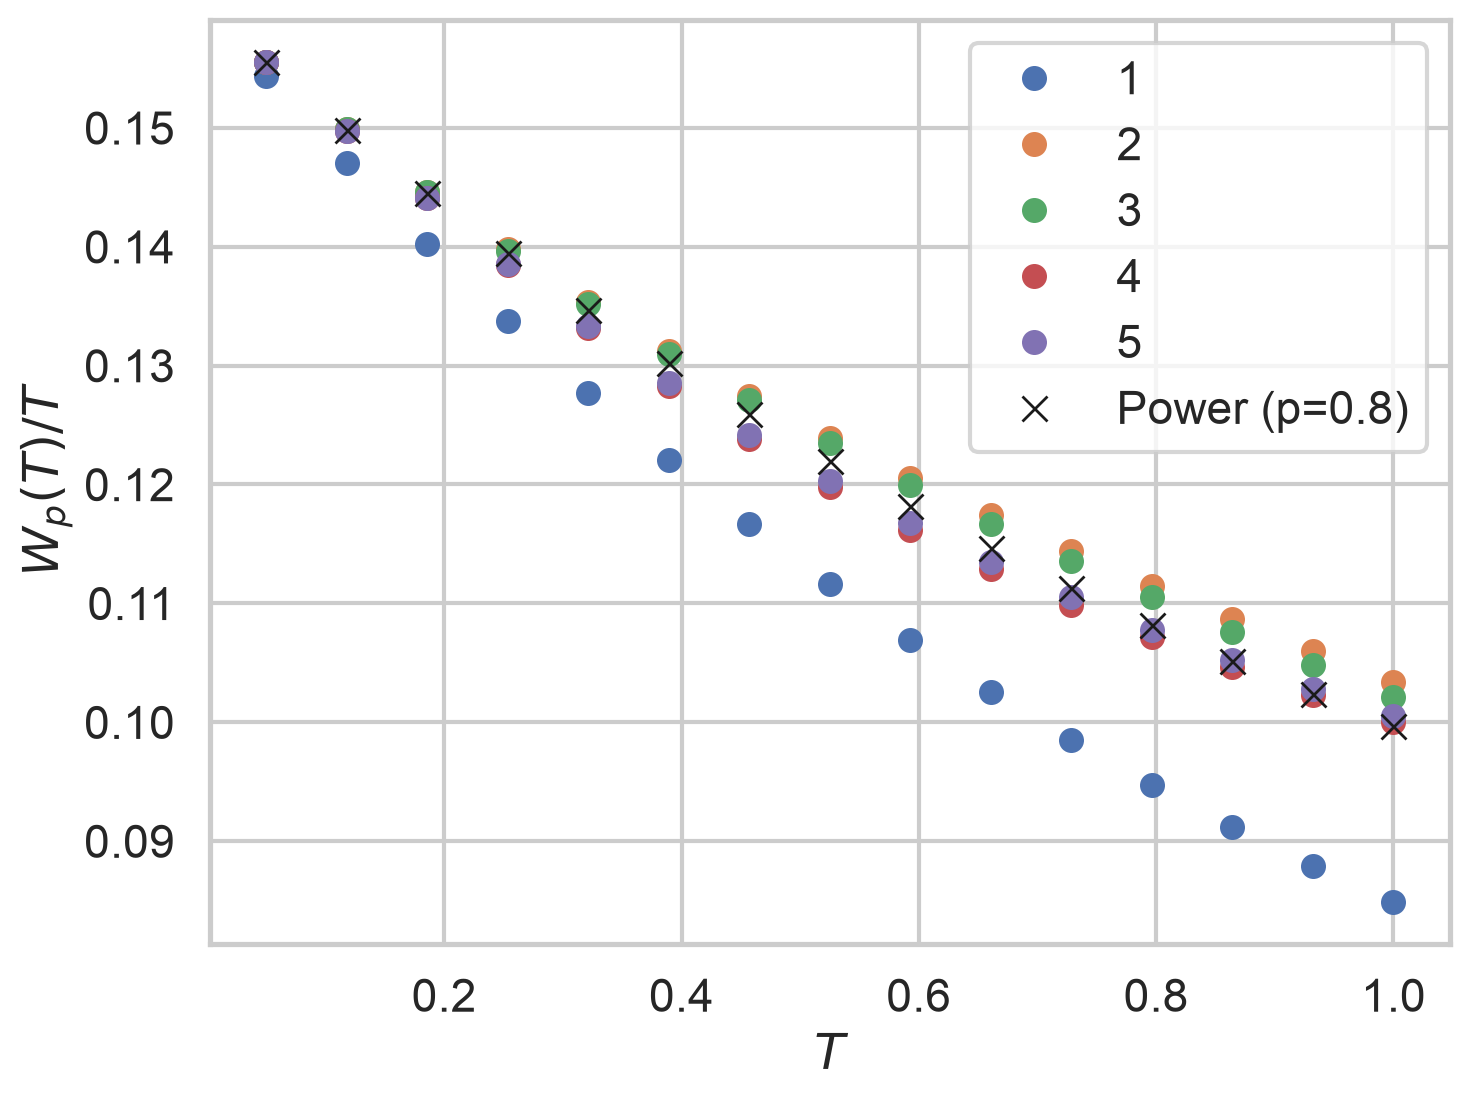

In [49]:
# Plot power contract vs magic strike approximations
fig, ax = plt.subplots()
for order in POWER_ORDERS:
    ax.plot(
        Ts,
        power_var_magic_strikes[order] / Ts,
        ".",
        markersize=16,
        label=rf"{order}",
    )
ax.plot(Ts, power_var / Ts, "kx", label=f"Power (p={p})")
ax.legend()
ax.set_xlabel("$T$")
ax.set_ylabel(r"$W_p(T) / T$")
if SAVEFIG:
    fig.savefig(
        f"figures/power_magic_strikes_heston_set_{set_id}.pdf",
        bbox_inches="tight",
    )
plt.show()